In [1]:
import numpy as np
import pandas as pd
from torch.fx.experimental.unification.multipledispatch.dispatcher import source

In [2]:
book=pd.read_csv('rigel_customer_interviews_codebook.csv')
real=pd.read_csv('rigel_customer_interviews_realistic_1248.csv')

In [24]:
book.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   column_name  15 non-null     object
 1   description  15 non-null     object
dtypes: object(2)
memory usage: 372.0+ bytes


In [82]:
real.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 40 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   interview_id                        1248 non-null   object 
 1   interview_date                      1248 non-null   object 
 2   customer_type                       1248 non-null   object 
 3   role_title                          1248 non-null   object 
 4   organization_type                   1248 non-null   object 
 5   province_or_region                  1248 non-null   object 
 6   sub_region                          1248 non-null   object 
 7   company_size_band                   1248 non-null   object 
 8   years_experience                    1248 non-null   int64  
 9   interview_channel                   1248 non-null   object 
 10  source_channel                      1248 non-null   object 
 11  interaction_stage                   1248 no

In [1]:
import os
os.system('open .')

0

In [5]:
import pandas as pd

pd.DataFrame({
    "A":[1,2,3],
    "B":[4,5,6]
}).to_csv("test.csv", index=False)

In [97]:
real.groupby(['interview_channel','source_channel'])[['interview_channel','source_channel']].value_counts()

interview_channel             source_channel      
Community governance session  Conference / event        3
                              Existing network          5
                              Inbound website           3
                              Outbound outreach         8
                              Partner introduction      8
                              Referral                  9
In person                     Conference / event       34
                              Existing network         19
                              Inbound website          19
                              Outbound outreach        40
                              Partner introduction     38
                              Referral                 71
Phone                         Conference / event       16
                              Existing network         21
                              Inbound website          20
                              Outbound outreach        50
                     

In [100]:
user_channel = real.groupby(['customer_type','decision_role'])[['interview_channel','source_channel']].value_counts()
user_channel

customer_type                 decision_role   interview_channel             source_channel      
Advisor                       Decision-maker  Zoom                          Referral                18
                                                                            Outbound outreach       15
                                              Phone                         Outbound outreach       11
                                                                            Referral                11
                                              Zoom                          Conference / event      11
                                                                                                    ..
Indigenous Governance Office  Influencer      Community governance session  Partner introduction     2
                                              In person                     Existing network         2
                                              Zoom                          Out

In [85]:
print(user_channel.columns)
print(user_channel.head())


Index(['customer_type', 'interview_channel', 'source_channel', 'count'], dtype='object')
  customer_type interview_channel        source_channel  count
0       Advisor              Zoom              Referral     41
1       Advisor              Zoom     Outbound outreach     38
2       Advisor              Zoom  Partner introduction     36
3       Advisor             Phone              Referral     33
4       Advisor             Phone     Outbound outreach     30


In [80]:
real.groupby('customer_type')[['interview_channel', 'source_channel']].value_counts(normalize=True)


customer_type                 interview_channel             source_channel      
Advisor                       Zoom                          Referral                0.096698
                                                            Outbound outreach       0.089623
                                                            Partner introduction    0.084906
                              Phone                         Referral                0.077830
                                                            Outbound outreach       0.070755
                                                                                      ...   
Indigenous Governance Office  In person                     Existing network        0.016064
                              Pilot debrief                 Existing network        0.016064
                              Zoom                          Existing network        0.016064
                              Community governance session  Conference / event    

In [40]:
real.groupby('customer_type')['customer_type'].count()

customer_type
Advisor                         424
Enterprise                      275
Estate Planner                  300
Indigenous Governance Office    249
Name: customer_type, dtype: int64

In [41]:
real['company_size_band'].value_counts()

company_size_band
2-10 staff                319
11-50 staff               279
Solo / very small team    277
51-250 staff              217
250+ staff                156
Name: count, dtype: int64

In [4]:
first_require = real['must_haves'].str.split(';').explode().str.strip().value_counts()
print(first_require)

must_haves
Reliability in live meetings                              230
Deterministic, auditable logic                            219
Meeting-ready answer screen                               214
Scenario comparisons that reuse existing data             213
Household intake in under 10 minutes                      211
One-click PDF/CSV export                                  201
Calculation appendix for deeper review                    189
Beneficiary and distribution clarity with gap flags       183
Single source of truth for estate flow logic              181
Traceability and versioning                               177
Explicit bypass vs through-estate mapping                 164
Deterministic show-your-work outputs                      152
Standardized outputs across teams                         151
Transparent Section 87 handling with explicit logic       151
First-class Indigenous trust workflows                    145
Exportable, meeting-ready reporting                       1

In [3]:
first_require = (
    real['must_haves']
    .str.split(';')
    .explode()
    .str.strip()
    .value_counts(normalize=True)
)

print(first_require)

must_haves
Reliability in live meetings                              0.061928
Deterministic, auditable logic                            0.058966
Meeting-ready answer screen                               0.057620
Scenario comparisons that reuse existing data             0.057351
Household intake in under 10 minutes                      0.056812
One-click PDF/CSV export                                  0.054120
Calculation appendix for deeper review                    0.050889
Beneficiary and distribution clarity with gap flags       0.049273
Single source of truth for estate flow logic              0.048735
Traceability and versioning                               0.047658
Explicit bypass vs through-estate mapping                 0.044157
Deterministic show-your-work outputs                      0.040926
Standardized outputs across teams                         0.040657
Transparent Section 87 handling with explicit logic       0.040657
First-class Indigenous trust workflows             

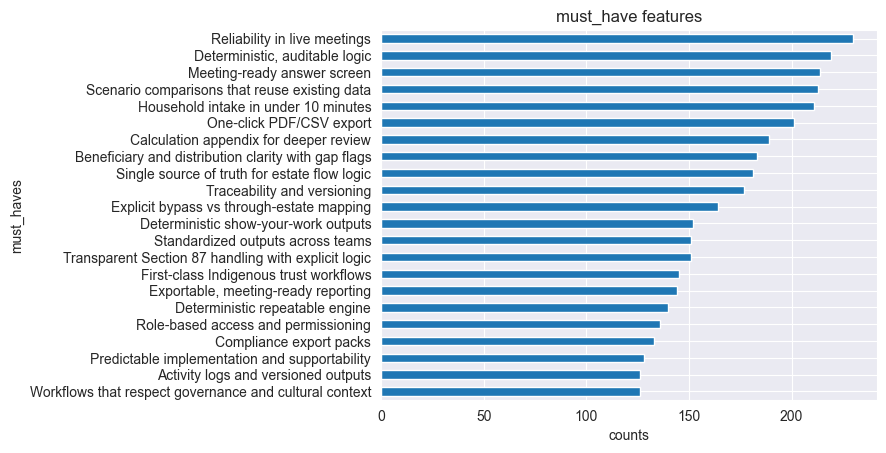

In [5]:
import matplotlib.pyplot as plt

first_require.plot(kind='barh')
plt.title('must_have features')
plt.xlabel('counts')
plt.gca().invert_yaxis()
plt.show()

In [44]:
nice_have=real['nice_to_haves'].str.split(';').explode().str.strip().value_counts()
print(nice_have)

nice_to_haves
Explainable equity scoring                              162
Visualisation of competing distribution scenarios       152
Audience-specific export packs                          144
Optional guided intake prompts                          143
Polished visuals if explainable                         137
Scenario modelling beyond top three client questions    136
Lightweight document vault                              125
Pre-filled templates                                    112
Packaged exports by audience                            111
Admin dashboard with usage visibility                   106
Flexible workflow configurations by Nation              102
Community-facing summaries                              101
Light adoption analytics                                 94
Simple rollout controls                                  94
Templates for leadership reporting                       93
Plain-language packs for beneficiaries and families      87
Name: count, dtype: int64


In [5]:
nice_require = (
    real['nice_to_haves']
    .str.split(';')
    .explode()
    .str.strip()
    .value_counts(normalize=True)
)

print(nice_require)

nice_to_haves
Explainable equity scoring                              0.085308
Visualisation of competing distribution scenarios       0.080042
Audience-specific export packs                          0.075829
Optional guided intake prompts                          0.075303
Polished visuals if explainable                         0.072143
Scenario modelling beyond top three client questions    0.071617
Lightweight document vault                              0.065824
Pre-filled templates                                    0.058978
Packaged exports by audience                            0.058452
Admin dashboard with usage visibility                   0.055819
Flexible workflow configurations by Nation              0.053712
Community-facing summaries                              0.053186
Light adoption analytics                                0.049500
Simple rollout controls                                 0.049500
Templates for leadership reporting                      0.048973
Plain-langu

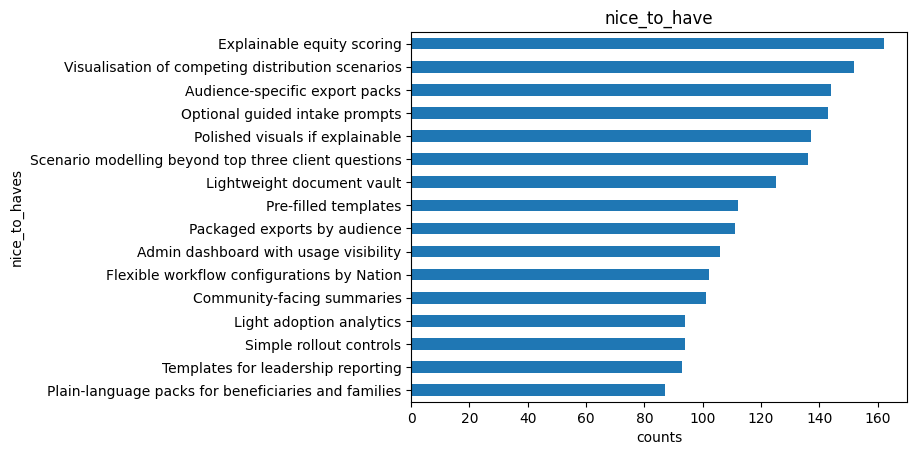

In [13]:
nice_have.plot(kind='barh')
plt.title('nice_to_have')
plt.xlabel('counts')
plt.gca().invert_yaxis()
plt.show()

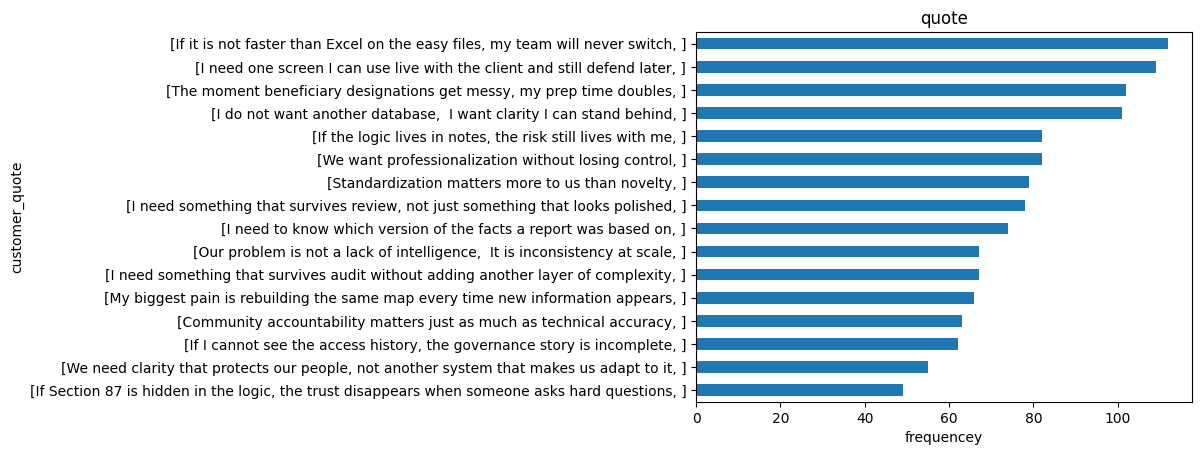

In [45]:
quote = real['customer_quote'].str.split('.').value_counts()
quote.plot(kind='barh')
plt.title('quote')
plt.xlabel('frequencey')
plt.gca().invert_yaxis()
plt.show()

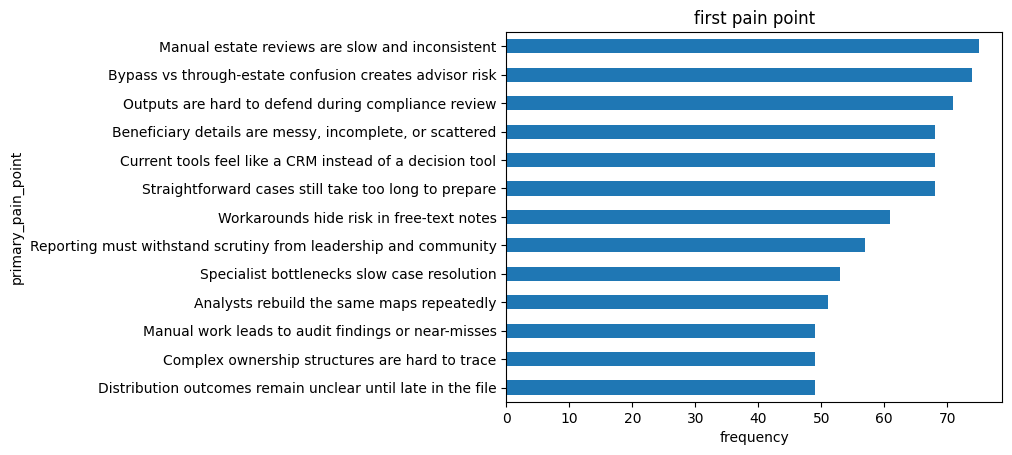

In [15]:
counts = real['primary_pain_point'].value_counts()
first_pain = counts[counts >= 49]# total 24 rows，choose 12 rows
first_pain.plot(kind='barh')
plt.xlabel('frequency')
plt.title('first pain point')
plt.gca().invert_yaxis()
plt.show()

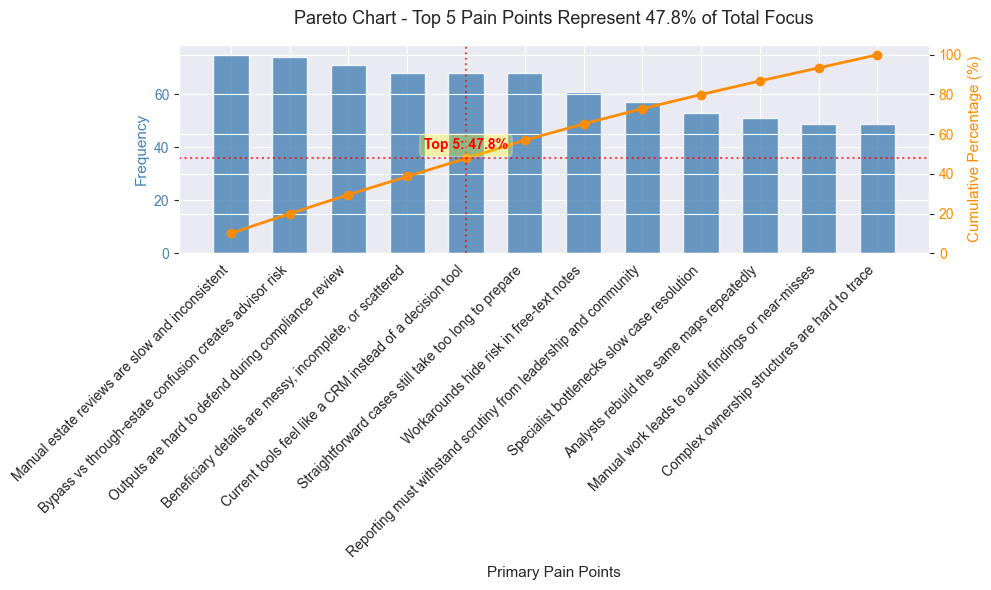

In [4]:
import matplotlib.pyplot as plt
import pandas as pd


counts = real['primary_pain_point'].value_counts()
first_pain = counts[counts >= 49].head(12)

df_pareto = pd.DataFrame({'frequency': first_pain})
df_pareto['cumulative_sum'] = df_pareto['frequency'].cumsum()
total_frequency = df_pareto['frequency'].sum()
df_pareto['cumulative_perc'] = (df_pareto['cumulative_sum'] / total_frequency) * 100


top5_name = df_pareto.index[4]
top5_perc = df_pareto['cumulative_perc'].iloc[4]


fig, ax1 = plt.subplots(figsize=(10, 6))


ax1.bar(df_pareto.index, df_pareto['frequency'], color='steelblue', alpha=0.8, width=0.6)
ax1.set_xlabel('Primary Pain Points', fontsize=11)
ax1.set_ylabel('Frequency', color='steelblue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='steelblue')
plt.xticks(rotation=45, ha='right')


ax2 = ax1.twinx()
ax2.plot(df_pareto.index, df_pareto['cumulative_perc'], color='darkorange', marker='o', ms=6, linewidth=2)
ax2.set_ylabel('Cumulative Percentage (%)', color='darkorange', fontsize=11)
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylim(0, 105)


# x axis 5th point draw vertical line
ax2.axvline(x=4, color='red', linestyle=':', alpha=0.7)
# curve 5th point draw horizon line
ax2.axhline(y=top5_perc, color='red', linestyle=':', alpha=0.7)

# curve 5th point interpret the first 5 column percentage
ax2.text(4, top5_perc + 3, f'Top 5: {top5_perc:.1f}%',
         color='red', fontweight='bold', ha='center', va='bottom',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))


plt.title(f'Pareto Chart - Top 5 Pain Points Represent {top5_perc:.1f}% of Total Focus', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

In [46]:
counts

primary_pain_point
Manual estate reviews are slow and inconsistent                        75
Bypass vs through-estate confusion creates advisor risk                74
Outputs are hard to defend during compliance review                    71
Beneficiary details are messy, incomplete, or scattered                68
Current tools feel like a CRM instead of a decision tool               68
Straightforward cases still take too long to prepare                   68
Workarounds hide risk in free-text notes                               61
Reporting must withstand scrutiny from leadership and community        57
Specialist bottlenecks slow case resolution                            53
Analysts rebuild the same maps repeatedly                              51
Manual work leads to audit findings or near-misses                     49
Complex ownership structures are hard to trace                         49
Distribution outcomes remain unclear until late in the file            49
Governance expectat

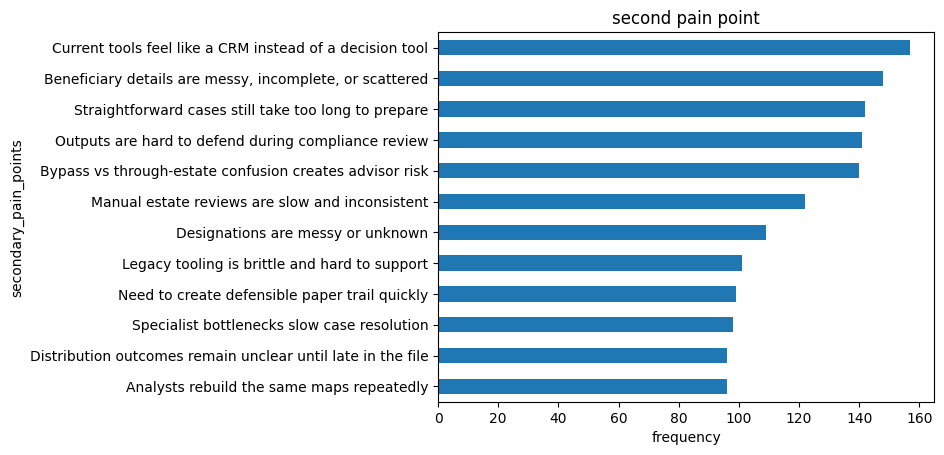

In [21]:
number = real['secondary_pain_points'].str.split(';').explode().str.strip().value_counts()
number.head(12).plot(kind='barh')# total 24 rows
plt.xlabel('frequency')
plt.title('second pain point')
plt.gca().invert_yaxis()
plt.show()

In [48]:
number

secondary_pain_points
Current tools feel like a CRM instead of a decision tool               157
Beneficiary details are messy, incomplete, or scattered                148
Straightforward cases still take too long to prepare                   142
Outputs are hard to defend during compliance review                    141
Bypass vs through-estate confusion creates advisor risk                140
Manual estate reviews are slow and inconsistent                        122
Designations are messy or unknown                                      109
Legacy tooling is brittle and hard to support                          101
Need to create defensible paper trail quickly                           99
Specialist bottlenecks slow case resolution                             98
Distribution outcomes remain unclear until late in the file             96
Analysts rebuild the same maps repeatedly                               96
Inconsistent processes across regions and teams                         94
Com

In [70]:
interview_result = real['interview_summary'].str.split('.').explode().str.strip()
interview_result = interview_result[interview_result != ""]
interview_result.value_counts()

interview_summary
Interviewee wants a workflow that is clearly faster than spreadsheet prep for straightforward files       424
Strong emphasis on a single answer screen for live client conversations                                   353
Interview centred on reducing manual rebuilds of estate flow maps across complex files                    300
Respondent wants documentation that can withstand review by lawyers, accountants, and compliance teams    300
Interview focused on standardization, governance, and operational control across teams                    275
Modernization interest is real, but rollout risk and supportability remain major concerns                 275
Bypass versus through-estate treatment came up as a recurring source of risk                              264
Interview emphasized accountability to leadership and community alongside technical rigour                249
Section 87 handling must be explicit, reviewable, and easy to explain                                 

In [72]:
plt.rcdefaults()

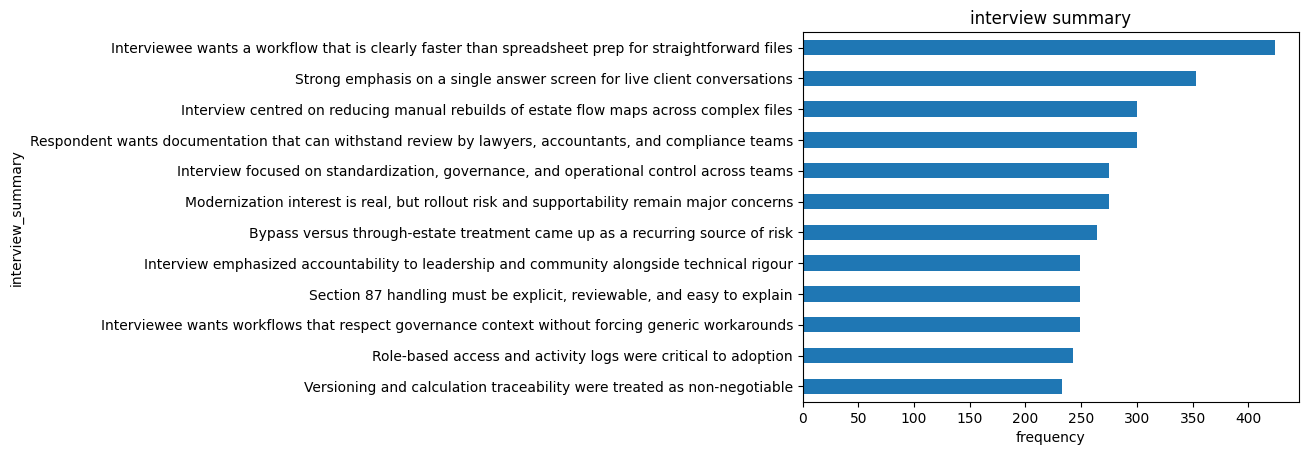

In [74]:
summry_number = interview_result.value_counts()
summry_number.plot(kind='barh')
plt.xlabel('frequency')
plt.title('interview summary')
plt.gca().invert_yaxis()
plt.show()

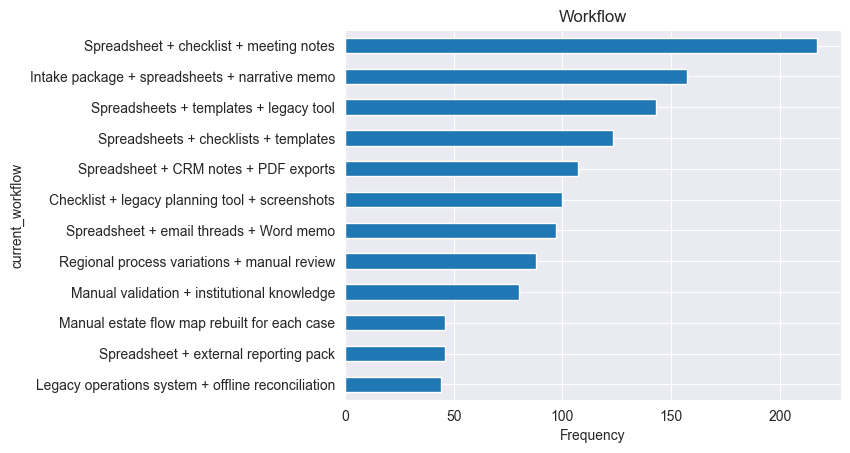

In [3]:
import matplotlib.pyplot as plt
workflow_number = real['current_workflow'].value_counts()
workflow_number.plot(kind='barh')
plt.title("Workflow")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.show()

In [4]:
real['current_workflow'].value_counts(normalize=True)

current_workflow
Spreadsheet + checklist + meeting notes              0.173878
Intake package + spreadsheets + narrative memo       0.125801
Spreadsheets + templates + legacy tool               0.114583
Spreadsheets + checklists + templates                0.098558
Spreadsheet + CRM notes + PDF exports                0.085737
Checklist + legacy planning tool + screenshots       0.080128
Spreadsheet + email threads + Word memo              0.077724
Regional process variations + manual review          0.070513
Manual validation + institutional knowledge          0.064103
Manual estate flow map rebuilt for each case         0.036859
Spreadsheet + external reporting pack                0.036859
Legacy operations system + offline reconciliation    0.035256
Name: proportion, dtype: float64

In [9]:
workflow_number

current_workflow
Spreadsheet + checklist + meeting notes              217
Intake package + spreadsheets + narrative memo       157
Spreadsheets + templates + legacy tool               143
Spreadsheets + checklists + templates                123
Spreadsheet + CRM notes + PDF exports                107
Checklist + legacy planning tool + screenshots       100
Spreadsheet + email threads + Word memo               97
Regional process variations + manual review           88
Manual validation + institutional knowledge           80
Manual estate flow map rebuilt for each case          46
Spreadsheet + external reporting pack                 46
Legacy operations system + offline reconciliation     44
Name: count, dtype: int64

In [4]:
buying = real['buying_triggers'].value_counts()
print(buying)


buying_triggers
Team wants faster pre-meeting preparation                                                                                          57
Rising compliance pressure                                                                                                         54
Backlog of estate review work                                                                                                      51
Need to standardize outputs across a branch                                                                                        44
Increase in disputed or unequal distribution files                                                                                 41
                                                                                                                                   ..
Need to standardize outputs across a branch; Backlog of estate review work                                                          8
Desire to standardize workflow while maintaini

In [7]:
buy_reason = real['buying_triggers'].str.split(';').explode().str.strip()
buy_reason.value_counts()


buying_triggers
Team wants faster pre-meeting preparation                             176
Backlog of estate review work                                         165
Rising compliance pressure                                            158
Need to standardize outputs across a branch                           143
Increase in disputed or unequal distribution files                    122
Errors and omissions risk in manual workflows                         111
Too much analyst time spent rebuilding maps                           111
Pressure to deliver faster without compromising rigour                111
Cost reduction mandate                                                111
New trust mandate or increase in trust complexity                     105
Need to reduce manual rework and specialist hours                     104
Modernization initiative                                               99
Regulatory or compliance event                                         98
Desire to standardize 

In [11]:
import pandas as pd


category_map = {
    'Spreadsheet + checklist + meeting notes': 'Spreadsheet-workflow',
    'Spreadsheet + CRM notes + PDF exports': 'Spreadsheet-workflow',
    'Spreadsheet + email threads + Word memo': 'Spreadsheet-workflow',
    'Spreadsheet + external reporting pack': 'Spreadsheet-workflow',
    'Spreadsheets + checklists + templates': 'Spreadsheet-workflow',
    'Intake package + spreadsheets + narrative memo': 'Intake & template',
    'Spreadsheets + templates + legacy tool': 'Intake & template',
    'Checklist + legacy planning tool + screenshots': 'Legacy-workflows',
    'Legacy operations system + offline reconciliation': 'Legacy-workflows',
    'Regional process variations + manual review': 'Manual & institution-dependent',
    'Manual validation + institutional knowledge ': 'Manual & institution-dependent',
    'Manual estate flow map rebuilt for each case': 'Manual & institution-dependent'
}


workflow_series = real['current_workflow'].str.strip().reset_index(drop=True)

# use replace instead of map + fillna，keep original data if not matched
mapped_workflows = workflow_series.replace(category_map)


print(mapped_workflows.value_counts())


current_workflow
Spreadsheet-workflow                           590
Intake & template                              300
Legacy-workflows                               144
Manual & institution-dependent                 134
Manual validation + institutional knowledge     80
Name: count, dtype: int64


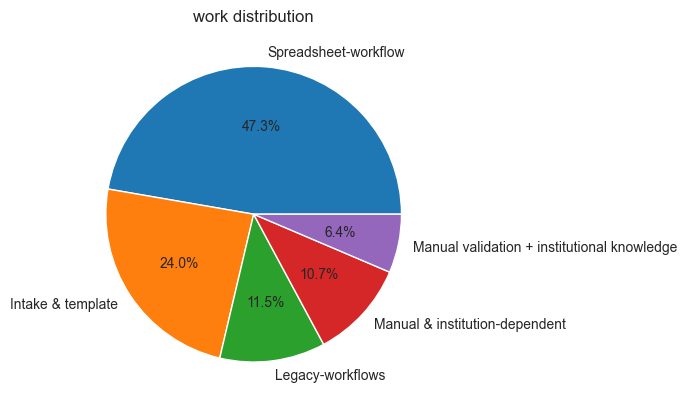

In [10]:
import matplotlib.pyplot as plt

plt.pie(
    mapped_workflows.value_counts(),
    labels=mapped_workflows.value_counts().index,
    autopct='%1.1f%%',

)
plt.title("work distribution")

plt.show()

In [13]:
primary = real['primary_pain_point'].str.split(';')
secondary = real['secondary_pain_points'].str.split(';')
all_pain = primary + secondary
pain_df = all_pain.explode().str.strip()

In [14]:
pain_theme_map = {
    'Manual estate reviews are slow and inconsistent': 'Workflow inefficiency',
    'Straightforward cases still take too long to prepare': 'Workflow inefficiency',

    'Bypass vs through-estate confusion creates advisor risk': 'Estate flow confusion',

    'Outputs are hard to defend during compliance review': 'Compliance defensibility',

    'Beneficiary details are messy, incomplete, or scattered': 'Data quality issues',

    'Current tools feel like a CRM instead of a decision tool': 'Tool frustration'
}
pain_theme = pain_df.map(pain_theme_map)
pain_theme.value_counts()

Workflow inefficiency       407
Tool frustration            225
Data quality issues         216
Estate flow confusion       214
Compliance defensibility    212
Name: count, dtype: int64

In [ ]:
plt.pie(
    pain_theme.value_counts(),
    labels=pain_theme.value_counts().index,
    autopct='%1.1f%%',

)

In [17]:
trigger_theme_map = {
    # Faster preparation pressure
    'Team wants faster pre-meeting preparation':'Faster preparation pressure',
    'Pressure to deliver faster without compromising rigour':'Faster preparation pressure',

    # Compliance & risk pressure
    'Rising compliance pressure':'Compliance & risk pressure',
    'Regulatory or compliance event':'Compliance & risk pressure',
    'Errors and omissions risk in manual workflows':'Compliance & risk pressure',
    'Pressure for clearer reporting and defensible administration': 'Compliance & risk pressure',

    # Standardization needs
    'Need to standardize outputs across a branch':'Standardization needs',
    'Desire to standardize workflow while maintaining community control':'Standardization needs',

    # Operational efficiency
    'Backlog of estate review work':'Operational efficiency',
    'Too much analyst time spent rebuilding maps':'Operational efficiency',
    'Need to reduce manual rework and specialist hours':'Operational efficiency',
    'Cost reduction mandate':'Operational efficiency',

    # Organizational modernization
    'Modernization initiative':'Organizational modernization',

    'New trust mandate or increase in trust complexity':'Organizational modernization',

    'Growth in reporting expectations from leadership or members':'Organizational modernization',

    'Increase in disputed or unequal distribution files':'Organizational modernization'
}
trigger_df = real['buying_triggers'].str.split(';').explode().str.strip()

trigger_theme = trigger_df.map(trigger_theme_map)

trigger_theme.value_counts()

buying_triggers
Operational efficiency          491
Compliance & risk pressure      461
Organizational modernization    410
Faster preparation pressure     287
Standardization needs           241
Name: count, dtype: int64

In [4]:
customer_tool = real.groupby("customer_type")["current_workflow"].value_counts()
print(customer_tool)

customer_type                 current_workflow                                 
Advisor                       Spreadsheet + checklist + meeting notes              217
                              Spreadsheet + CRM notes + PDF exports                107
                              Checklist + legacy planning tool + screenshots       100
Enterprise                    Spreadsheets + templates + legacy tool               143
                              Regional process variations + manual review           88
                              Legacy operations system + offline reconciliation     44
Estate Planner                Intake package + spreadsheets + narrative memo       157
                              Spreadsheet + email threads + Word memo               97
                              Manual estate flow map rebuilt for each case          46
Indigenous Governance Office  Spreadsheets + checklists + templates                123
                              Manual validation + 

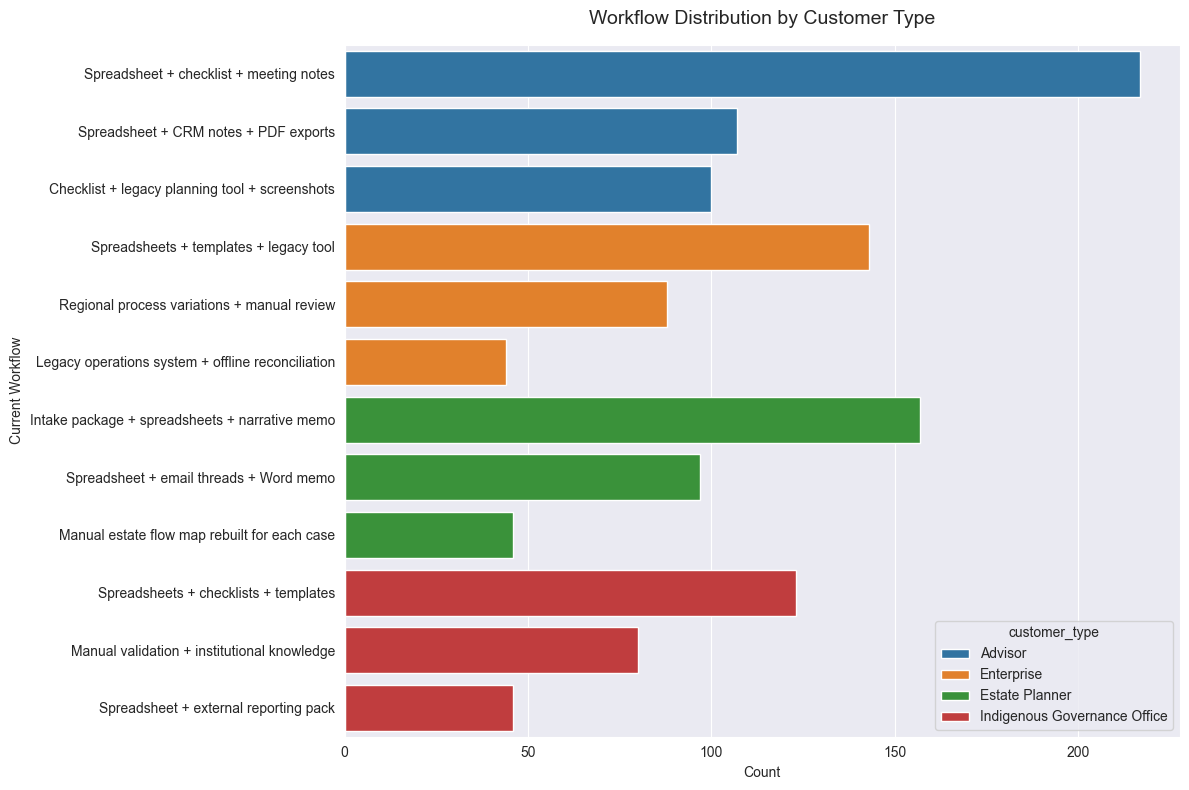

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


df_plot = real.groupby("customer_type")["current_workflow"].value_counts().reset_index(name="count")


plt.figure(figsize=(12, 8))


sns.barplot(
    data=df_plot,
    x="count",
    y="current_workflow",
    hue="customer_type"
)


plt.title("Workflow Distribution by Customer Type", fontsize=14, pad=15)
plt.xlabel("Count")
plt.ylabel("Current Workflow")
plt.tight_layout()

plt.show()
